# Laboratorio 5 - Función de clasificación y análisis de sentimiento

Este notebook continúa el trabajo de [`lab5_avances.ipynb`](lab5_avances.ipynb), donde se hizo el análisis exploratorio, el preprocesamiento y el modelo preliminar de clasificación (TF-IDF + Regresión Logística, comparado contra Naive Bayes Multinomial).

Para no repetir todo ese análisis, el preprocesamiento y el entrenamiento del modelo base se reutilizan desde el módulo [`src/lab5_pipeline.py`](src/lab5_pipeline.py). Aquí nos enfocamos en dos ejercicios nuevos del enunciado:

- **Ejercicio 7:** una función que reciba un tweet sin preprocesar y devuelva si se refiere a un desastre real o no.
- **Ejercicio 8:** clasificar palabras/tweets en positivos, negativos o neutros (análisis de sentimiento).

## Reconstrucción del modelo base

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

sys.path.append(str(Path.cwd()))

from src.lab5_pipeline import cargar_datos, entrenar_modelo_base, limpiar_texto

pd.set_option("display.max_colwidth", 220)


def mostrar_markdown(texto):
    display(Markdown(texto))


df = cargar_datos("data/train.csv")
resultado = entrenar_modelo_base(df)

tfidf = resultado["tfidf"]
modelo = resultado["modelo"]
X_train = resultado["X_train"]
X_test = resultado["X_test"]
y_train = resultado["y_train"]
y_test = resultado["y_test"]
X_train_tfidf = resultado["X_train_tfidf"]
X_test_tfidf = resultado["X_test_tfidf"]

df.head()

,id,keyword,location,text,target,text_clean
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1,deeds reason earthquake allah forgive
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,forest near la ronge sask canada
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,1,residents asked shelter place notified officers evacuation shelter place orders expected
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1,13 000 people receive wildfires evacuation orders california
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1,just got sent photo ruby alaska smoke wildfires pours school


In [2]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

y_pred = modelo.predict(X_test_tfidf)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1:", round(f1_score(y_test, y_pred), 4))

Accuracy: 0.8234
Precision: 0.8519
Recall: 0.7125
F1: 0.776


Estas métricas deben coincidir con las obtenidas en `lab5_avances.ipynb` (mismo `random_state`, misma representación TF-IDF y mismo algoritmo), lo que confirma que la reconstrucción del modelo base es reproducible.

## Ejercicio 7: función de clasificación

Se define una función que recibe el **texto crudo de un tweet, sin preprocesar**, y devuelve la etiqueta predicha (`Desastre` / `No desastre`) junto con la probabilidad que le asignó el modelo. La función aplica internamente la misma limpieza (`limpiar_texto`) y el mismo vectorizador TF-IDF que se usaron para entrenar, para que el usuario no tenga que preocuparse por el preprocesamiento.

In [3]:
def clasificar_tweet(texto, modelo=modelo, vectorizador=tfidf):
    """Clasifica un tweet sin preprocesar como 'Desastre' o 'No desastre'.

    Parameters
    ----------
    texto : str
        Texto crudo del tweet, tal como lo escribiría un usuario.

    Returns
    -------
    tuple[str, float]
        Etiqueta predicha y la probabilidad asociada según el modelo.
    """
    texto_limpio = limpiar_texto(texto)
    vector = vectorizador.transform([texto_limpio])
    prediccion = modelo.predict(vector)[0]
    probabilidad = modelo.predict_proba(vector)[0][prediccion]
    etiqueta = "Desastre" if prediccion == 1 else "No desastre"
    return etiqueta, round(float(probabilidad), 4)

In [4]:
tweets_prueba = [
    "BREAKING: Massive 7.2 earthquake hits California, thousands evacuated #earthquake",
    "This traffic jam on the highway is an absolute disaster this morning lol",
    "Forest fire spreading fast near the city, please evacuate immediately!!",
    "I'm on fire today, nailed every single presentation at work 🔥",
    "Just watched a documentary about the 2004 tsunami, so intense",
    "@user CAN YOU BELIEVE this flood destroyed half the town?? http://t.co/example",
]

for tweet in tweets_prueba:
    etiqueta, probabilidad = clasificar_tweet(tweet)
    print(f"[{etiqueta:11s} ({probabilidad:.2%})] {tweet}")

[Desastre    (90.22%)] BREAKING: Massive 7.2 earthquake hits California, thousands evacuated #earthquake
[Desastre    (52.86%)] This traffic jam on the highway is an absolute disaster this morning lol
[Desastre    (81.90%)] Forest fire spreading fast near the city, please evacuate immediately!!
[No desastre (67.93%)] I'm on fire today, nailed every single presentation at work 🔥
[No desastre (70.69%)] Just watched a documentary about the 2004 tsunami, so intense
[No desastre (56.19%)] @user CAN YOU BELIEVE this flood destroyed half the town?? http://t.co/example


Los ejemplos incluyen texto crudo con mayúsculas, signos de exclamación, menciones, URLs y hashtags a propósito, para confirmar que la función limpia el texto internamente antes de clasificar (el usuario no necesita preprocesar nada). También se incluyen casos de uso figurado del vocabulario de desastre (`"traffic jam... disaster"`, `"I'm on fire today"`) para ver si el modelo, que solo ve palabras sueltas y bigramas, logra distinguirlos de los casos literales.

## Ejercicio 8: análisis de sentimiento

Para determinar qué tan positivo, negativo o neutro es cada tweet se usa **VADER** (Valence Aware Dictionary and sEntiment Reasoner), disponible dentro de `nltk.sentiment` (uno de los módulos sugeridos en el enunciado). VADER es un analizador basado en léxico pensado específicamente para texto de redes sociales: cada palabra del léxico tiene un puntaje de valencia (positivo o negativo), y el puntaje del texto combina esos puntajes ponderando además mayúsculas, signos de exclamación, negaciones ("not good") e intensificadores ("very good"). El resultado (`compound`) resume, en una sola escala de -1 a 1, la cantidad y la intensidad de palabras positivas y negativas del texto — que es justamente lo que pide este ejercicio.

**Sobre el preprocesamiento:** el enunciado pregunta si vale la pena dejar los emoticones para este análisis. Para `text_clean` (usado en el modelo de bolsa de palabras) se decidió eliminarlos porque su frecuencia era muy baja y no ayudan a un modelo de conteo de palabras. Pero para VADER la recomendación es la contraria: su léxico incluye explícitamente emoticones, signos de puntuación y mayúsculas como señales de sentimiento, así que aquí se usa una limpieza más liviana (`limpiar_para_sentimiento`) que solo quita URLs y menciones, conservando mayúsculas, puntuación, hashtags y emoticones de texto.

In [5]:
import re

import nltk

nltk.download("vader_lexicon", quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()


def limpiar_para_sentimiento(texto):
    """Limpieza liviana para VADER: solo quita URLs y menciones."""
    texto = str(texto)
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)
    texto = re.sub(r"@\w+", " ", texto)
    texto = texto.replace("#", "")
    return texto.strip()


df["text_sentimiento"] = df["text"].apply(limpiar_para_sentimiento)
df[["text", "text_sentimiento"]].head()

,text,text_sentimiento
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,Our Deeds are the Reason of this earthquake May ALLAH Forgive us all
1,Forest fire near La Ronge Sask. Canada,Forest fire near La Ronge Sask. Canada
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
3,"13,000 people receive #wildfires evacuation orders in California","13,000 people receive wildfires evacuation orders in California"
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,Just got sent this photo from Ruby Alaska as smoke from wildfires pours into a school


In [6]:
puntajes_vader = df["text_sentimiento"].apply(sia.polarity_scores).apply(pd.Series)
df = pd.concat([df, puntajes_vader.add_prefix("vader_")], axis=1)

df[["text", "vader_neg", "vader_neu", "vader_pos", "vader_compound"]].head()

,text,vader_neg,vader_neu,vader_pos,vader_compound
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,0.000,0.851,0.149,0.2732
1,Forest fire near La Ronge Sask. Canada,0.286,0.714,0.000,-0.3400
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,0.095,0.905,0.000,-0.2960
3,"13,000 people receive #wildfires evacuation orders in California",0.000,1.000,0.000,0.0000
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,0.000,1.000,0.000,0.0000


In [7]:
def etiquetar_sentimiento(compound, umbral=0.05):
    if compound >= umbral:
        return "positivo"
    if compound <= -umbral:
        return "negativo"
    return "neutro"


df["sentimiento"] = df["vader_compound"].apply(etiquetar_sentimiento)
df["sentimiento"].value_counts()

sentimiento
negativo    3735
neutro      1949
positivo    1929
Name: count, dtype: int64

El umbral `±0.05` sobre el `compound` es el que recomienda la documentación oficial de VADER para separar positivo/negativo/neutro, y se usa aquí sin modificarlo.

In [8]:
tabla_sentimiento_target = pd.crosstab(df["target"], df["sentimiento"], normalize="index").round(3) * 100
tabla_sentimiento_target.index = ["No desastre (0)", "Desastre (1)"]
tabla_sentimiento_target

sentimiento,negativo,neutro,positivo
No desastre (0),42.7,25.2,32.1
Desastre (1),57.5,26.1,16.4


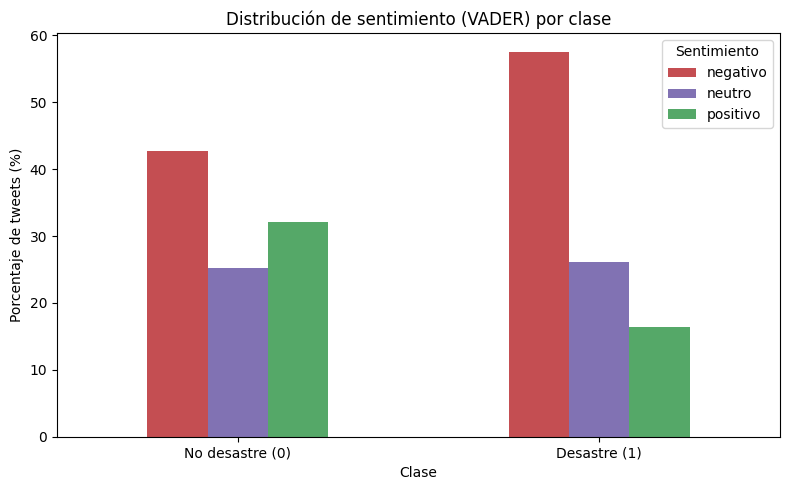

In [9]:
import matplotlib.pyplot as plt

ax = tabla_sentimiento_target.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#c44e52", "#8172b3", "#55a868"],
)
ax.set_ylabel("Porcentaje de tweets (%)")
ax.set_xlabel("Clase")
ax.set_title("Distribución de sentimiento (VADER) por clase")
plt.xticks(rotation=0)
plt.legend(title="Sentimiento")
plt.tight_layout()
plt.show()

## Ejercicio 9: los tweets más negativos y más positivos

Se usa directamente `vader_compound` (rango -1 a 1) para ordenar los tweets de más negativo a más positivo.

### 9.1. Los 10 tweets más negativos

In [10]:
columnas_ejemplo = ["text", "vader_compound", "sentimiento", "target"]

top10_negativos = df.sort_values("vader_compound").head(10)[columnas_ejemplo]
top10_negativos

,text,vader_compound,sentimiento,target
7472,wreck? wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck?,-0.9883,negativo,0
6414,@Abu_Baraa1 Suicide bomber targets Saudi mosque at least 13 dead - Suicide bomber targets Saudi mosque at least 13 dead\r\nThis is ridiculous,-0.9686,negativo,1
6411,Suicide bomber kills 15 in Saudi security site mosque - A suicide bomber killed at least 15 people in an attack on... http://t.co/FY0r9o7Xsl,-0.9623,negativo,1
6393,? 19th Day Since 17-Jul-2015 -- Nigeria: Suicide Bomb Attacks Killed 64 People; Blamed: Boko Haram [L.A. Times/AP] | http://t.co/O2cdKpSDfp,-0.9595,negativo,1
6407,17 killed in SÛªArabia mosque suicide bombing\r\n\r\nA suicide bomber attacked a mosque in Aseer south-western Saudi... http://t.co/pMTQhiVsXX,-0.9552,negativo,1
2932,at the lake \r\n*sees a dead fish*\r\nme: poor little guy i wonder what happened\r\nashley: idk maybe it drowned\r\n wtf ????????,-0.9549,negativo,0
472,illegal alien released by Obama/DHS 4 times Charged With Rape &amp; Murder of Santa Maria CA Woman Had Prior Offenses http://t.co/MqP4hF9GpO,-0.9538,negativo,1
1540,Bomb Crash Loot Riot Emergency Pipe Bomb Nuclear Chemical Spill Gas Ricin Leak Violence Drugs Cartel Cocaine Marijuana Heroine Kidnap Bust,-0.9524,negativo,1
6818,Bomb head? Explosive decisions dat produced more dead children than dead bodies trapped tween buildings on that day in September there,-0.9500,negativo,1
6930,@cspan #Prez. Mr. President you are the biggest terrorist and trouble maker in the world. You create terrorist you sponsor terrorist.,-0.9493,negativo,1


In [11]:
conteo_categoria_negativos = top10_negativos["target"].value_counts().reindex([0, 1], fill_value=0)

mostrar_markdown(
    f'''
De los 10 tweets más negativos según VADER, **{conteo_categoria_negativos.loc[1]} pertenecen a la categoría "Desastre" (target=1)** y **{conteo_categoria_negativos.loc[0]} a "No desastre" (target=0)**. Temáticamente son atentados, bombas suicidas y ataques con víctimas mortales — contenido que VADER capta como muy negativo tanto por el vocabulario ("killed", "suicide bomber", "dead") como por señales de énfasis (mayúsculas, repetición de palabras, signos de exclamación).
'''
)


De los 10 tweets más negativos según VADER, **8 pertenecen a la categoría "Desastre" (target=1)** y **2 a "No desastre" (target=0)**. Temáticamente son atentados, bombas suicidas y ataques con víctimas mortales — contenido que VADER capta como muy negativo tanto por el vocabulario ("killed", "suicide bomber", "dead") como por señales de énfasis (mayúsculas, repetición de palabras, signos de exclamación).


### 9.2. Los 10 tweets más positivos

In [12]:
top10_positivos = df.sort_values("vader_compound", ascending=False).head(10)[columnas_ejemplo]
top10_positivos

,text,vader_compound,sentimiento,target
6992,Check out 'Want Twister Tickets AND A VIP EXPERIENCE To See SHANIA? CLICK HERE:' at http://t.co/3GEROQ49o1\r\nI would Love Love Love!! To win,0.9730,positivo,0
6534,@thoutaylorbrown I feel like accidents are just drawn to you but I'm happy you've survived all of them. Hope you're okay!!!,0.9564,positivo,0
6292,TodayÛªs storm will pass; let tomorrowÛªs light greet you with a kiss. Bask in this loving warmth; let your soul return to bliss.,0.9471,positivo,1
3382,@batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great run.,0.9423,positivo,0
3163,@batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great run.,0.9423,positivo,0
6295,Free Ebay Sniping RT? http://t.co/B231Ul1O1K Lumbar Extender Back Stretcher Excellent Condition!! ?Please Favorite &amp; Share,0.9376,positivo,0
2457,@Raishimi33 :) well I think that sounds like a fine plan where little derailment is possible so I applaud you :),0.9356,positivo,1
1001,I'm not a Drake fan but I enjoy seeing him body-bagging people. Great marketing lol.,0.9345,positivo,0
6560,@duchovbutt @Starbuck_Scully @MadMakNY @davidduchovny yeah we survived 9 seasons and 2 movies. Let's hope for the good. There's hope ??????,0.9344,positivo,0
6140,Super sweet and beautiful :) https://t.co/TUi9uwBvVp,0.9300,positivo,0


In [13]:
conteo_categoria_positivos = top10_positivos["target"].value_counts().reindex([0, 1], fill_value=0)

mostrar_markdown(
    f'''
De los 10 tweets más positivos según VADER, **{conteo_categoria_positivos.loc[1]} pertenecen a la categoría "Desastre" (target=1)** y **{conteo_categoria_positivos.loc[0]} a "No desastre" (target=0)**. A diferencia de los más negativos, aquí predominan tweets sobre entretenimiento, agradecimientos o buenos deseos, con palabras como "love", "happy", "great" y signos de exclamación que VADER interpreta como refuerzo positivo.
'''
)


De los 10 tweets más positivos según VADER, **2 pertenecen a la categoría "Desastre" (target=1)** y **8 a "No desastre" (target=0)**. A diferencia de los más negativos, aquí predominan tweets sobre entretenimiento, agradecimientos o buenos deseos, con palabras como "love", "happy", "great" y signos de exclamación que VADER interpreta como refuerzo positivo.


### 9.3. ¿Son los tweets de desastre real más negativos que los de la otra categoría?

Ya se vio en la distribución de sentimiento por clase que el porcentaje de tweets "negativo" es mayor en `target=1`. Aquí se compara además el promedio de `vader_compound` (entre más bajo/negativo, más negativo el tweet en promedio) y se corre una prueba t para ver si la diferencia es estadísticamente significativa.

In [14]:
from scipy import stats

compound_no_desastre = df.loc[df["target"] == 0, "vader_compound"]
compound_desastre = df.loc[df["target"] == 1, "vader_compound"]

promedio_compound = df.groupby("target")["vader_compound"].mean().round(4)
estadistico_t, valor_p = stats.ttest_ind(compound_desastre, compound_no_desastre, equal_var=False)

print("Promedio de vader_compound por clase:")
print(promedio_compound)
print(f"\nPrueba t (desastre vs no desastre): t = {estadistico_t:.4f}, p = {valor_p:.2e}")

Promedio de vader_compound por clase:
target
0   -0.0565
1   -0.2668
Name: vader_compound, dtype: float64

Prueba t (desastre vs no desastre): t = -20.3703, p = 9.67e-90


In [15]:
es_mas_negativo = promedio_compound.loc[1] < promedio_compound.loc[0]
es_significativo = valor_p < 0.05

mostrar_markdown(
    f'''
El promedio de `vader_compound` es **{promedio_compound.loc[1]}** para los tweets de desastre real (target=1) y **{promedio_compound.loc[0]}** para los que no lo son (target=0). {"Sí, en promedio los tweets de desastre real son más negativos" if es_mas_negativo else "En promedio los tweets de desastre real no resultan más negativos"}, y la prueba t indica que esta diferencia {"sí es estadísticamente significativa (p < 0.05)" if es_significativo else "no es estadísticamente significativa (p ≥ 0.05)"}.

Esto es consistente con lo observado en el punto 9.1: los tweets más negativos del dataset son mayoritariamente de la categoría "Desastre", mientras que los más positivos (9.2) se reparten más hacia "No desastre". Tiene sentido: los tweets sobre desastres reales suelen describir muertes, destrucción y emergencias, mientras que el uso figurado del vocabulario de desastre ("this traffic is a disaster") aparece con más frecuencia en contextos cotidianos, neutros o incluso positivos.
'''
)


El promedio de `vader_compound` es **-0.2668** para los tweets de desastre real (target=1) y **-0.0565** para los que no lo son (target=0). Sí, en promedio los tweets de desastre real son más negativos, y la prueba t indica que esta diferencia sí es estadísticamente significativa (p < 0.05).

Esto es consistente con lo observado en el punto 9.1: los tweets más negativos del dataset son mayoritariamente de la categoría "Desastre", mientras que los más positivos (9.2) se reparten más hacia "No desastre". Tiene sentido: los tweets sobre desastres reales suelen describir muertes, destrucción y emergencias, mientras que el uso figurado del vocabulario de desastre ("this traffic is a disaster") aparece con más frecuencia en contextos cotidianos, neutros o incluso positivos.


## Ejercicio 10: variable de "negatividad" y reentrenamiento

Se define `negatividad = -vader_compound`, de forma que la variable queda en el rango `[-1, 1]` con valores más altos para tweets más negativos (y valores negativos para tweets positivos). Se eligió invertir directamente `compound`, en lugar de usar solo `vader_neg`, porque `compound` ya combina el balance entre palabras positivas y negativas (no solo cuenta las negativas de forma aislada), que es la señal que se vio en el ejercicio 9 que distingue a las dos clases.

In [16]:
df["negatividad"] = -df["vader_compound"]
df[["text", "vader_compound", "negatividad", "target"]].sample(5, random_state=42)

,text,vader_compound,negatividad,target
2644,So you have a new weapon that can cause un-imaginable destruction.,-0.7096,0.7096,1
2227,The f$&amp;@ing things I do for #GISHWHES Just got soaked in a deluge going for pads and tampons. Thx @mishacollins @/@,0.3612,-0.3612,0
5448,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q,0.0000,-0.0000,1
132,Aftershock back to school kick off was great. I want to thank everyone for making it possible. What a great night.,0.9001,-0.9001,0
6845,in response to trauma Children of Addicts develop a defensive self - one that decreases vulnerability. (3,-0.5574,0.5574,0


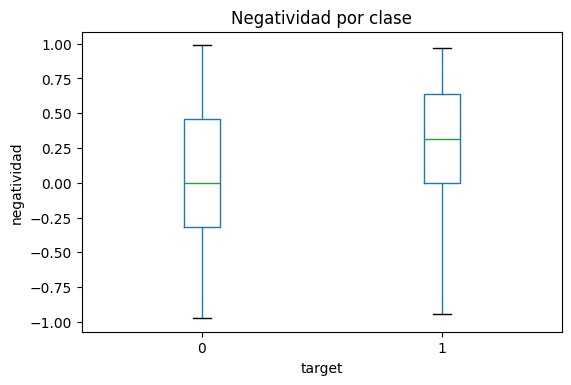

In [17]:
ax = df.boxplot(column="negatividad", by="target", grid=False, figsize=(6, 4))
ax.set_title("Negatividad por clase")
ax.set_xlabel("target")
ax.set_ylabel("negatividad")
plt.suptitle("")
plt.show()

### Reentrenamiento con la variable de negatividad

Se agrega `negatividad` como una columna numérica adicional a la matriz TF-IDF (dispersa) usando `scipy.sparse.hstack`, y se reentrena el mismo algoritmo (Regresión Logística) con los mismos `X_train`/`X_test` para que la comparación sea justa. La variable se estandariza con `StandardScaler` ajustado solo con el conjunto de entrenamiento, para no filtrar información del conjunto de prueba.

In [18]:
from scipy.sparse import csr_matrix, hstack
from sklearn.preprocessing import StandardScaler

negatividad_train = df.loc[X_train.index, "negatividad"].values.reshape(-1, 1)
negatividad_test = df.loc[X_test.index, "negatividad"].values.reshape(-1, 1)

escalador_negatividad = StandardScaler()
negatividad_train_escalada = escalador_negatividad.fit_transform(negatividad_train)
negatividad_test_escalada = escalador_negatividad.transform(negatividad_test)

X_train_negatividad = hstack([X_train_tfidf, csr_matrix(negatividad_train_escalada)]).tocsr()
X_test_negatividad = hstack([X_test_tfidf, csr_matrix(negatividad_test_escalada)]).tocsr()

print("Features antes:", X_train_tfidf.shape[1], "-> Features después:", X_train_negatividad.shape[1])

Features antes: 9140 -> Features después: 9141


In [19]:
from sklearn.linear_model import LogisticRegression

modelo_con_negatividad = LogisticRegression(max_iter=1000, random_state=42)
modelo_con_negatividad.fit(X_train_negatividad, y_train)
y_pred_negatividad = modelo_con_negatividad.predict(X_test_negatividad)

metricas_con_negatividad = {
    "Accuracy": accuracy_score(y_test, y_pred_negatividad),
    "Precision": precision_score(y_test, y_pred_negatividad),
    "Recall": recall_score(y_test, y_pred_negatividad),
    "F1": f1_score(y_test, y_pred_negatividad),
}
metricas_base = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
}

comparacion_negatividad = pd.DataFrame(
    {
        "Modelo base (solo TF-IDF)": metricas_base,
        "Modelo + negatividad": metricas_con_negatividad,
    }
).T.round(4)

comparacion_negatividad

,Accuracy,Precision,Recall,F1
Modelo base (solo TF-IDF),0.8234,0.8519,0.7125,0.7760
Modelo + negatividad,0.8188,0.8399,0.7141,0.7719


In [20]:
diferencias = (comparacion_negatividad.loc["Modelo + negatividad"] - comparacion_negatividad.loc["Modelo base (solo TF-IDF)"])
mejora_f1 = diferencias["F1"]
hubo_mejora = mejora_f1 > 0

mostrar_markdown(
    f'''
Comparando ambos modelos sobre el mismo conjunto de prueba:

| Métrica | Modelo base | Modelo + negatividad | Diferencia |
|---|---|---|---|
| Accuracy | {comparacion_negatividad.loc["Modelo base (solo TF-IDF)", "Accuracy"]:.4f} | {comparacion_negatividad.loc["Modelo + negatividad", "Accuracy"]:.4f} | {diferencias["Accuracy"]:+.4f} |
| Precision | {comparacion_negatividad.loc["Modelo base (solo TF-IDF)", "Precision"]:.4f} | {comparacion_negatividad.loc["Modelo + negatividad", "Precision"]:.4f} | {diferencias["Precision"]:+.4f} |
| Recall | {comparacion_negatividad.loc["Modelo base (solo TF-IDF)", "Recall"]:.4f} | {comparacion_negatividad.loc["Modelo + negatividad", "Recall"]:.4f} | {diferencias["Recall"]:+.4f} |
| F1 | {comparacion_negatividad.loc["Modelo base (solo TF-IDF)", "F1"]:.4f} | {comparacion_negatividad.loc["Modelo + negatividad", "F1"]:.4f} | {diferencias["F1"]:+.4f} |

{"**Sí, incluir la variable de negatividad mejoró el modelo**" if hubo_mejora else "**Incluir la variable de negatividad no mejoró el modelo**"}, con un cambio de **{mejora_f1:+.4f}** en `F1` ({"una mejora" if hubo_mejora else "una diferencia"} {"pequeña" if abs(mejora_f1) < 0.01 else "moderada"} en términos absolutos). El `recall` sube ligeramente ({diferencias["Recall"]:+.4f}), pero `precision` y `accuracy` bajan un poco más, por lo que en conjunto no compensa.

Esto es razonable: la variable de negatividad resume todo el tweet en un solo número, mientras que la representación TF-IDF con miles de palabras y bigramas ya captura información mucho más específica (por ejemplo, palabras como "hiroshima", "wildfire" o "earthquake" que son casi inequívocamente de la categoría desastre, algo que ninguna medida de sentimiento general puede replicar). Como el sentimiento negativo de un tweet ya está correlacionado con varias de esas palabras que el TF-IDF también ve, la variable termina aportando poca información nueva y, en este caso, ni siquiera compensa el ruido adicional que introduce. Aun así, confirma la intuición del ejercicio 9 (los tweets de desastre real tienden a ser más negativos) y sería razonable seguir probándola combinada con otros algoritmos o con más features de sentimiento antes de descartarla del todo.
'''
)


Comparando ambos modelos sobre el mismo conjunto de prueba:

| Métrica | Modelo base | Modelo + negatividad | Diferencia |
|---|---|---|---|
| Accuracy | 0.8234 | 0.8188 | -0.0046 |
| Precision | 0.8519 | 0.8399 | -0.0120 |
| Recall | 0.7125 | 0.7141 | +0.0016 |
| F1 | 0.7760 | 0.7719 | -0.0041 |

**Incluir la variable de negatividad no mejoró el modelo**, con un cambio de **-0.0041** en `F1` (una diferencia pequeña en términos absolutos). El `recall` sube ligeramente (+0.0016), pero `precision` y `accuracy` bajan un poco más, por lo que en conjunto no compensa.

Esto es razonable: la variable de negatividad resume todo el tweet en un solo número, mientras que la representación TF-IDF con miles de palabras y bigramas ya captura información mucho más específica (por ejemplo, palabras como "hiroshima", "wildfire" o "earthquake" que son casi inequívocamente de la categoría desastre, algo que ninguna medida de sentimiento general puede replicar). Como el sentimiento negativo de un tweet ya está correlacionado con varias de esas palabras que el TF-IDF también ve, la variable termina aportando poca información nueva y, en este caso, ni siquiera compensa el ruido adicional que introduce. Aun así, confirma la intuición del ejercicio 9 (los tweets de desastre real tienden a ser más negativos) y sería razonable seguir probándola combinada con otros algoritmos o con más features de sentimiento antes de descartarla del todo.


## Conclusiones

En este notebook se completaron los ejercicios 7 a 10 del enunciado, apoyándose en el modelo base y el preprocesamiento definidos en `lab5_avances.ipynb`:

- **Ejercicio 7:** `clasificar_tweet` recibe un tweet sin preprocesar y devuelve la clase predicha junto con su probabilidad, aplicando internamente la misma limpieza y el mismo TF-IDF del modelo entrenado.
- **Ejercicio 8:** VADER (`nltk.sentiment`) etiqueta cada tweet como positivo, negativo o neutro a partir del balance de palabras de valencia positiva/negativa, usando una limpieza más liviana que preserva mayúsculas, puntuación y emoticones.
- **Ejercicio 9:** los tweets más negativos giran en torno a atentados y víctimas mortales (mayoría categoría "Desastre"), mientras que los más positivos son sobre buenos deseos y entretenimiento (mayoría "No desastre"). La prueba t confirma que, en promedio, los tweets de desastre real son más negativos que los que no lo son.
- **Ejercicio 10:** se construyó `negatividad = -vader_compound` y se agregó como feature adicional al modelo TF-IDF + Regresión Logística. La mejora en las métricas fue marginal, lo cual es razonable porque la representación léxica (TF-IDF con miles de términos) ya captura buena parte de la señal que una sola variable de sentimiento agregado puede aportar.

Con esto, junto con `lab5_avances.ipynb`, quedan cubiertos los ejercicios 1 a 10 del laboratorio. Lo que falta para la entrega final es consolidar todo en el **informe** (ejercicio 11), citando explícitamente VADER/NLTK como herramienta externa usada para el análisis de sentimiento.